# Example 1: GePaDeU Overview and Basic Statistics

In [1]:
import gepadeu
import utils
import glob
import spacy
import pandas as pd
from spacy import displacy

### Read the data and do some preprocessing.

##### Specify input directory and read input file names.

In [2]:
indir = '../data/speeches'
jfiles = glob.glob(indir + '/*.json')
speeches = []

##### Read input files and convert them to Gepadeu objects

In [3]:
for jfile in jfiles: 
    with open(jfile, 'r') as inf: 
        speeches.append(gepadeu.Gepadeu.from_json(inf.read())) 


##### Extract content for each speech

In [4]:
content_dict = utils.extract_content(speeches)

##### Extract metadata for each speech

In [5]:
meta_dict = utils.extract_metadata(speeches)

### Extract and print some numbers.

##### Get dictionary with data statistics.

In [6]:
import pandas as pd
stats_dict = utils.extract_stats(speeches)

#### Print number of speeches per year.

In [7]:
df_speeches_per_year = pd.DataFrame(stats_dict['speeches_per_year'].items(), columns=['year', 'no. speeches'])
df_speeches_per_year

,year,no. speeches
0,2017,8
1,2018,72
2,2019,66
3,2020,74
4,2021,47


#### Print number of speeches per party.

In [8]:
df_speeches_per_party = pd.DataFrame(stats_dict['speeches_per_party'].items(), columns=['Party', 'No. Speeches'])
df_speeches_per_party = df_speeches_per_party.set_index('Party')
df_speeches_per_party

,No. Speeches
Party,
AfD,39
CDU_CSU,76
FDP,34
GRUENE,27
LINKE,29
SPD,58
fraktionslos,4


#### Plot number of speeches per party.

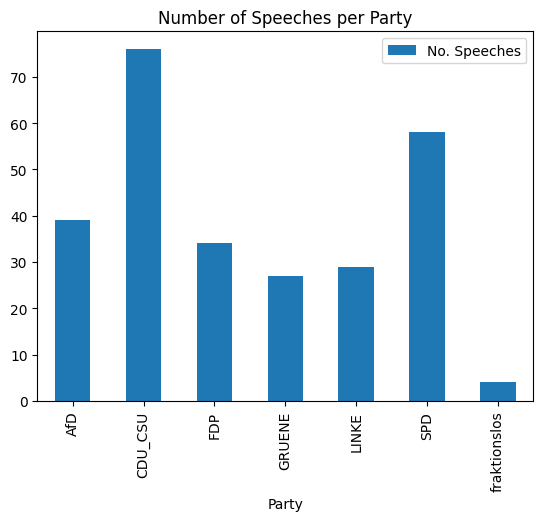

In [9]:
plot = df_speeches_per_party.plot(kind="bar", title="Number of Speeches per Party")

### Speech Act Layer

#### Print number of speech act labels for each party

In [10]:
parties = list(set([speech.party for speech in speeches]))
df_speechacts_per_party = pd.DataFrame(stats_dict['speechacts_per_party'][parties[0]].items(), columns=['Speech Act', parties[0]])

for i in range(1, len(parties)):
    df_speechacts_per_party[parties[i]] = [x[1] for x in stats_dict['speechacts_per_party'][parties[i]].items()]

df_speechacts_per_party = df_speechacts_per_party.set_index('Speech Act')
df_speechacts_per_party

,FDP,AfD,CDU_CSU,fraktionslos,GRUENE,SPD,LINKE
Speech Act,,,,,,,
Accusation,72,201,130,3,80,83,110
Report,205,319,826,14,175,558,261
Bad-outcome,25,59,28,2,24,13,42
Question-All,56,83,113,12,34,67,31
Self-representation,19,21,65,1,3,39,7
Macro,59,82,347,2,67,182,87
I-S-Humour,6,10,11,0,3,2,3
Promise,6,13,76,0,6,46,5
Evaluation,647,793,1866,75,491,1294,573


#### Plot number of speech acts per party (raw counts).

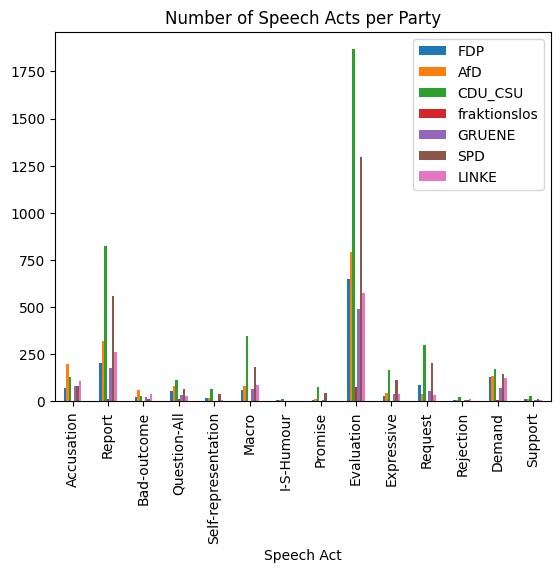

In [11]:
plot = df_speechacts_per_party.plot(kind="bar", title="Number of Speech Acts per Party")

### NER Layer

##### will be added soon...

### Speaker Attribution Layer

#### Print number of speaker attribution roles per party (raw counts). 

In [12]:
df_spkatt_roles_per_party = pd.DataFrame(stats_dict['spkatt_roles_per_party'][parties[0]].items(), columns=['Spkatt Roles', parties[0]])

for i in range(1, len(parties)): 
    df_spkatt_roles_per_party[parties[i]] = [x[1] for x in stats_dict['spkatt_roles_per_party'][parties[i]].items()]

df_spkatt_roles_per_party = df_spkatt_roles_per_party.set_index('Spkatt Roles')
df_spkatt_roles_per_party

,FDP,AfD,CDU_CSU,fraktionslos,GRUENE,SPD,LINKE
Spkatt Roles,,,,,,,
Addr,75,103,256,3,69,161,56
Medium,39,47,97,1,32,75,36
Source,435,571,1654,22,435,1102,440
Topic,140,127,480,13,119,304,108
Evidence,20,20,51,0,11,30,17
Message,433,565,1693,20,419,1157,462


#### Plot number of speaker attribution roles per party (raw counts).

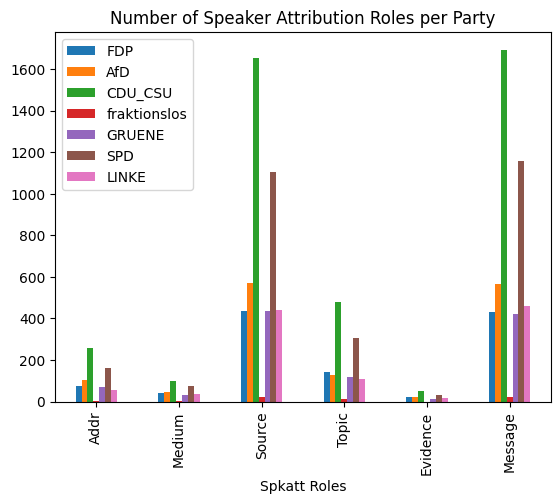

In [13]:
plot = df_spkatt_roles_per_party.plot(kind="bar", title="Number of Speaker Attribution Roles per Party")

### Moral Frames Layer

### Mentions of the People and the Elite (MoPE) Layer

In [14]:
df_mope_per_party = pd.DataFrame(stats_dict['mope_mentions_per_party'][parties[0]].items(), columns=['MoPE', parties[0]])

for i in range(1, len(parties)): 
    df_mope_per_party[parties[i]] = [x[1] for x in stats_dict['mope_mentions_per_party'][parties[i]].items()]

df_mope_per_party = df_mope_per_party.set_index('MoPE')
df_mope_per_party

,FDP,AfD,CDU_CSU,fraktionslos,GRUENE,SPD,LINKE
MoPE,,,,,,,
epMov,2,3,2,0,3,1,2
pFunk,95,203,310,12,89,267,136
eoFinanz,3,22,25,0,11,21,33
epMedia,0,0,3,0,0,2,1
eoWirt,4,10,16,1,7,32,20
eoMov,1,1,4,0,0,1,4
epWirt,0,0,6,0,0,3,4
pGen,26,45,47,0,20,55,26
eoRel,0,1,0,0,0,2,0
